# **Athletic Scholarship & Success** 

# **SUMMARY**

## **Data Compilation:**
## I complied data from DOE and NCAA to create a sheet that has median earnings, scholarship data, general tutition data etc. 

## **Hypothesis:** 
## My hypothesis is that higher athletic scholarship for atheltes will equate to high success later post gradution. These schools that have more money for athletic scholarship should hypothetically be able to prepare their students better for a post graduate experience. 

## **Method:**
## I am going to  convert scholarships and their general tution into a percetage to standardize it across all schools. I am splitting the data into four groups: Top 25 Male schools that provide highest scholarship, Bottom 25 Male schools that provide lowest scholarship, Top 25 Female schools that provide highest scholarship, Bottom 25 Female schools that provide lowest scholarship.

# **Results:** 

## **Hypothesis Clearly Wrong:**

### I was first under the impression that if an athelte gets a higher scholarship then perhaps they would have greater success after college. There wouldn't be as much debt, and these athletes in theory should have high ability and drive. Although at first glance of this data its seeming there is an opposite correlation. 

### Next steps: I'm now wondering if there is a correlation between amount these schools spend on sports vs. academics and median earnings post grad? Clearly AMOUNT of money is not an issue, is it possibly where the money goes?

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt


In [3]:
athletic_df = pd.read_excel('../data/athletic_scholarship_table.xlsx')

In [4]:
scholar_ME_df = pd.read_excel('../data/scholarship_and_ME.xlsx')

In [5]:
print(athletic_df.head(10))

                       NCAA_school        city  Unnamed: 2 state  division  \
0                              NaN         NaN         NaN   NaN       NaN   
1   University of Alaska Fairbanks   Fairbanks         NaN    AK  NCAA II    
2   University of Alaska Anchorage   Anchorage         NaN    AK  NCAA II    
3  Auburn University at Montgomery  Montgomery         NaN    AL  NCAA II    
4         Alabama State University  Montgomery         NaN    AL   NCAA  I   
5              Tuskegee University    Tuskegee         NaN    AL  NCAA II    
6         University of Montevallo  Montevallo         NaN    AL  NCAA II    
7               Samford University  Birmingham         NaN    AL   NCAA  I   
8              Spring Hill College      Mobile         NaN    AL  NCAA II    
9      University of South Alabama      Mobile         NaN    AL   NCAA  I   

   avg_men_scholarship  avg_women_scholarship  
0                  NaN                    NaN  
1              15340.0                12499.0

In [6]:
athletic_df["division"].unique()

<ArrowStringArray>
[       nan, 'NCAA II ',  'NCAA  I',    'NAIA ',   'NCAA I', 'NCAA  I ',
  'NCAA II', 'NCAA  II']
Length: 8, dtype: str

## Top 10 schools: Biggest athletic scholarships (Men & Women)

In [7]:
d1 = athletic_df[athletic_df["division"].isin(["NCAA I", "NCAAI"])]

top25_men = (
    d1[["NCAA_school", "avg_men_scholarship"]]
    .dropna()
    .sort_values("avg_men_scholarship", ascending=False)
    .head(25)
)


top25_women = (
    d1[["NCAA_school", "avg_women_scholarship"]]
    .dropna()
    .sort_values("avg_women_scholarship", ascending=False)
    .head(25)
)

print(top25_men)
print(top25_women)

                       NCAA_school  avg_men_scholarship
72   California Baptist University              19495.0
414              Merrimack College              16839.0
16     University of North Alabama              12730.0
                       NCAA_school  avg_women_scholarship
72   California Baptist University                25381.0
414              Merrimack College                17048.0
16     University of North Alabama                13121.0


### I want to do a map of these universities over a map that shows post grad earnings and see if there is correlation, id do two seperate maps for men and women (i know there is going to be some different in men vs. womens atheltic scholarships)

## Bottom 10 Schools: least amount of athletic scholarship (Men & Women)

In [8]:
d1 = athletic_df[athletic_df["division"].isin(["NCAA I", "NCAAI"])]

bottom25_men = (
    d1[["NCAA_school", "avg_men_scholarship"]]
    .dropna()
    .sort_values("avg_men_scholarship", ascending=False)
    .tail(25)
)


bottom25_women = (
    d1[["NCAA_school", "avg_women_scholarship"]]
    .dropna()
    .sort_values("avg_women_scholarship", ascending=False)
    .tail(25)
)

print(bottom25_men)
print(bottom25_women)

                       NCAA_school  avg_men_scholarship
72   California Baptist University              19495.0
414              Merrimack College              16839.0
16     University of North Alabama              12730.0
                       NCAA_school  avg_women_scholarship
72   California Baptist University                25381.0
414              Merrimack College                17048.0
16     University of North Alabama                13121.0


### I want to do the same map of these universities over a map that shows post grad earnings and see if there is correlation, id do two seperate maps for men and women (i know there is going to be some different in men vs. womens atheltic scholarships)

## Basic scholarship % the top 25 highest MALE scholarship schools 

In [14]:
print("Top Men:")
print((scholar_ME_df["tM25avg_scholar"] / scholar_ME_df["tM25_gen_tuition"]) * 100)

print("\nBottom Men:")
print((scholar_ME_df["bM25avg_scholar"] / scholar_ME_df["bM25_gen_tuition"]) * 100)

print("\nTop Women:")
print((scholar_ME_df["tF25avg_scholar"] / scholar_ME_df["tF25_gen_tuition"]) * 100)

print("\nBottom Women:")
print((scholar_ME_df["bF25avg_scholar"] / scholar_ME_df["bF25_gen_tuition"]) * 100)

Top Men:
0      96.043165
1      84.153994
2      88.946025
3      84.015587
4      85.112349
5      73.000863
6      87.288308
7      96.395719
8      64.352140
9      64.514750
10    101.048247
11    124.057839
12     92.829662
13     59.493232
14    104.850604
15     54.536707
16     53.754731
17     56.007779
18     84.370230
19     59.515793
20     55.808364
21    103.319008
22     53.114877
23     57.433499
24     54.833712
dtype: float64

Bottom Men:
0     49.634632
1     62.374582
2     46.732746
3     46.565245
4     16.191819
5     21.878097
6     45.826829
7     40.738652
8     43.824681
9     30.817474
10    43.776668
11    87.560070
12    46.497851
13    65.316497
14    17.095293
15    37.174976
16    51.014785
17    18.623740
18    87.796374
19    38.655967
20    37.878788
21    34.188169
22    28.793050
23    30.762702
24    48.687120
dtype: float64

Top Women:
0     281.187311
1      76.925759
2      82.383330
3      69.389483
4      73.462054
5      65.749663
6      72

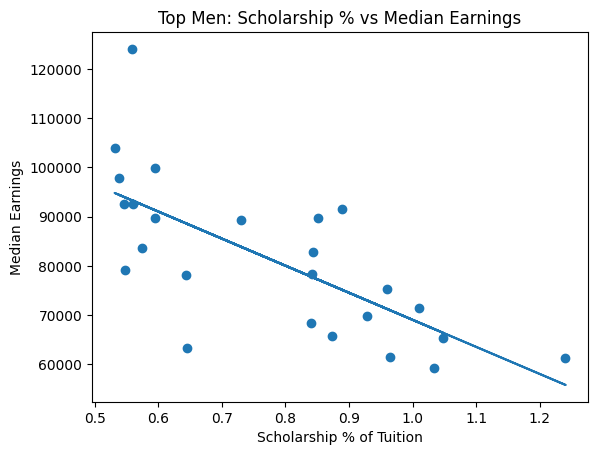

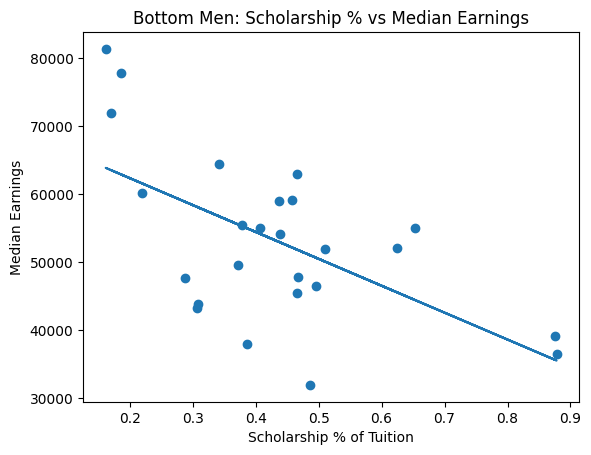

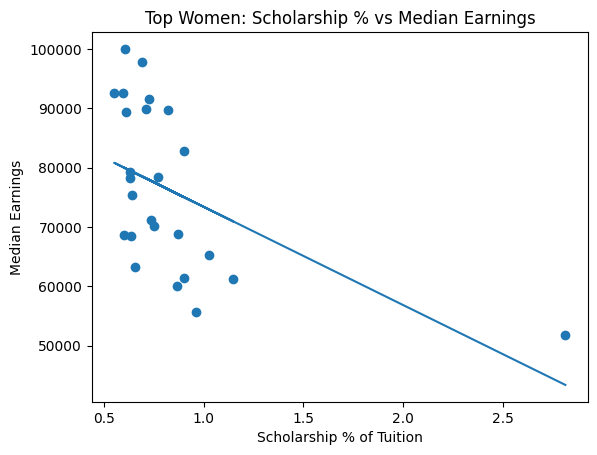

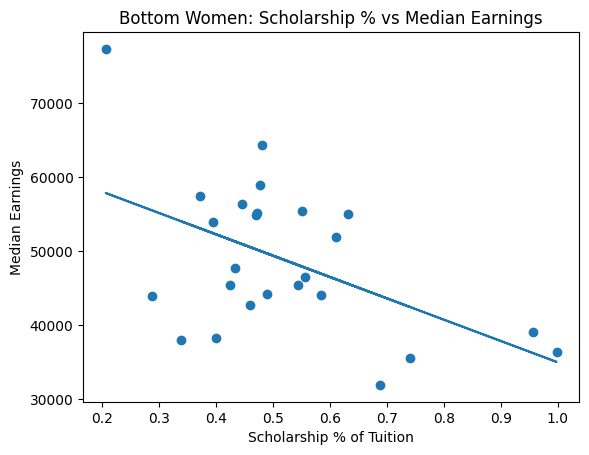

In [18]:
#Used claude to help organize the four different groups

#Top Men 
x = scholar_ME_df["tM25avg_scholar"] / scholar_ME_df["tM25_gen_tuition"]
y = scholar_ME_df["tM25_ME"]

plt.figure()
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)
plt.title("Top Men: Scholarship % vs Median Earnings")
plt.xlabel("Scholarship % of Tuition")
plt.ylabel("Median Earnings")
plt.show()


# Bottom Men 
x = scholar_ME_df["bM25avg_scholar"] / scholar_ME_df["bM25_gen_tuition"]
y = scholar_ME_df["bM25_ME"]

plt.figure()
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)
plt.title("Bottom Men: Scholarship % vs Median Earnings")
plt.xlabel("Scholarship % of Tuition")
plt.ylabel("Median Earnings")
plt.show()


# Top Women 
x = scholar_ME_df["tF25avg_scholar"] / scholar_ME_df["tF25_gen_tuition"]
y = scholar_ME_df["tF25_ME"]

plt.figure()
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)
plt.title("Top Women: Scholarship % vs Median Earnings")
plt.xlabel("Scholarship % of Tuition")
plt.ylabel("Median Earnings")
plt.show()


# Bottom Women
x = scholar_ME_df["bF25avg_scholar"] / scholar_ME_df["bF25_gen_tuition"]
y = scholar_ME_df["bF25_ME"]

plt.figure()
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)
plt.title("Bottom Women: Scholarship % vs Median Earnings")
plt.xlabel("Scholarship % of Tuition")
plt.ylabel("Median Earnings")
plt.show()

# **Results:** 

## **Hypothesis Clearly Wrong:**

### I was first under the impression that if an athelte gets a higher scholarship then perhaps they would have greater success after college. There wouldn't be as much debt, and these athletes in theory should have high ability and drive. Although at first glance of this data its seeming there is an opposite correlation.

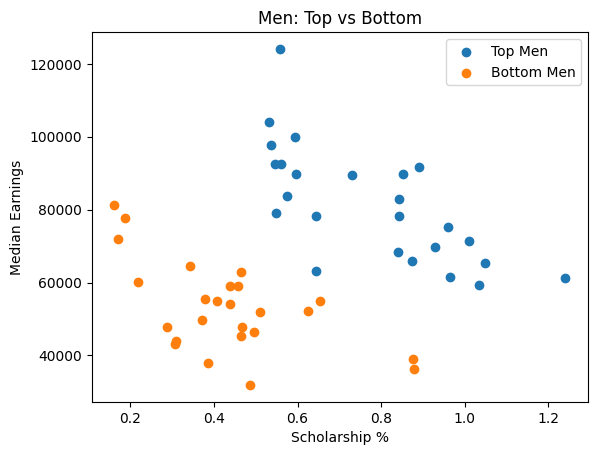

In [20]:
# Top Men
x1 = scholar_ME_df["tM25avg_scholar"] / scholar_ME_df["tM25_gen_tuition"]
y1 = scholar_ME_df["tM25_ME"]

# Bottom Men
x2 = scholar_ME_df["bM25avg_scholar"] / scholar_ME_df["bM25_gen_tuition"]
y2 = scholar_ME_df["bM25_ME"]

plt.figure()
plt.scatter(x1, y1, label="Top Men")
plt.scatter(x2, y2, label="Bottom Men")

plt.xlabel("Scholarship %")
plt.ylabel("Median Earnings")
plt.title("Men: Top vs Bottom")
plt.legend()
plt.show()

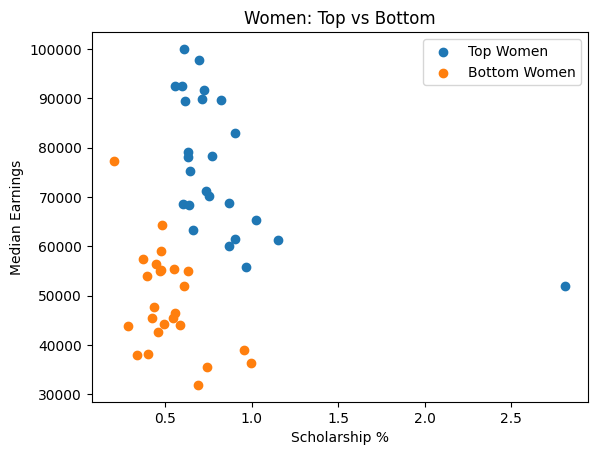

In [21]:
# Top Women
x1 = scholar_ME_df["tF25avg_scholar"] / scholar_ME_df["tF25_gen_tuition"]
y1 = scholar_ME_df["tF25_ME"]

# Bottom Women
x2 = scholar_ME_df["bF25avg_scholar"] / scholar_ME_df["bF25_gen_tuition"]
y2 = scholar_ME_df["bF25_ME"]

plt.figure()
plt.scatter(x1, y1, label="Top Women")
plt.scatter(x2, y2, label="Bottom Women")

plt.xlabel("Scholarship %")
plt.ylabel("Median Earnings")
plt.title("Women: Top vs Bottom")
plt.legend()
plt.show()